In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path("~/Documents/metrology_ir/vggt").expanduser()))

In [2]:
import torch
from vggt.models.vggt import VGGT
from vggt.utils.load_fn import load_and_preprocess_images

# !pip install open3d
import open3d as o3d


device = "cuda" if torch.cuda.is_available() else "cpu"
# bfloat16 is supported on Ampere GPUs (Compute Capability 8.0+) 
dtype = torch.bfloat16 if torch.cuda.get_device_capability()[0] >= 8 else torch.float16

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
# Initialize the model and load the pretrained weights.
# This will automatically download the model weights the first time it's run, which may take a while.
model = VGGT.from_pretrained("facebook/VGGT-1B").to(device)

In [4]:

# Load and preprocess example images (replace with your own image paths)
image_names = [
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/image/000000.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/image/000010.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/image/000020.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/image/000030.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/image/000040.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/image/000048.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/image/000005.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/image/000015.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/image/000025.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/image/000035.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/image/000045.png",
]
mask_names = [
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/mask/000.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/mask/010.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/mask/020.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/mask/030.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/mask/040.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/mask/048.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/mask/005.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/mask/015.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/mask/025.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/mask/035.png",
    "/home/ahc/Datasets/dtu/public_data/dtu/dtu_scan24/mask/045.png",
]
images = load_and_preprocess_images(image_names).to(device)
masks = load_and_preprocess_images(mask_names).to(device)
masks = masks.mean(dim=1) > 0.5

(np.float64(-0.5), np.float64(517.5), np.float64(391.5), np.float64(-0.5))

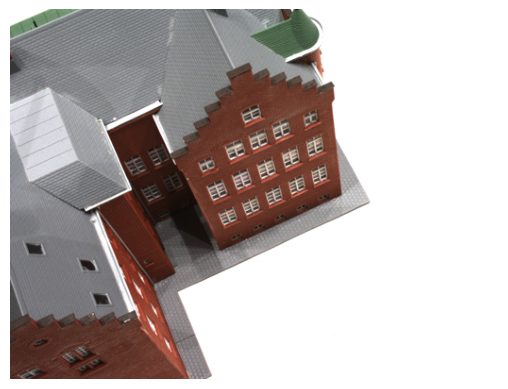

In [5]:
# !pip install matplotlib
from matplotlib import pyplot as plt

plt.imshow(images[0].cpu().permute(1, 2, 0))
plt.axis("off")

(np.float64(-0.5), np.float64(517.5), np.float64(391.5), np.float64(-0.5))

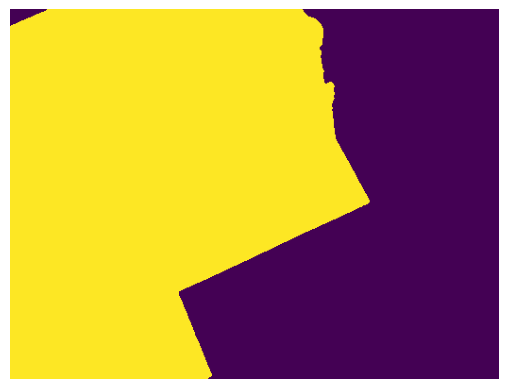

In [6]:
plt.imshow(masks[0].cpu())
plt.axis("off")

In [7]:

with torch.no_grad():
    with torch.cuda.amp.autocast(dtype=dtype):
        # Predict attributes including cameras, depth maps, and point maps.
        predictions = model(images)

In [8]:
predictions.keys()  # dict_keys(['cameras', 'depth_maps', 'point_maps'])

dict_keys(['pose_enc', 'pose_enc_list', 'depth', 'depth_conf', 'world_points', 'world_points_conf', 'images'])

In [9]:
print(predictions["world_points"].shape)
print(images.shape)
print(predictions["pose_enc"])

torch.Size([1, 11, 392, 518, 3])
torch.Size([11, 3, 392, 518])
tensor([[[-4.8857e-05,  6.0208e-05, -4.4288e-05, -3.5934e-06,  7.4403e-05,
          -1.0076e-04,  9.9991e-01,  4.0576e-01,  5.3086e-01],
         [-1.1641e-01, -1.5903e-01,  2.2673e-02, -7.6888e-02,  7.9950e-02,
           1.5100e-01,  9.8220e-01,  4.0778e-01,  5.3304e-01],
         [-4.2879e-01, -6.7445e-01,  4.9947e-01, -8.8182e-02,  5.2762e-01,
           6.2126e-01,  5.7325e-01,  4.1223e-01,  5.3872e-01],
         [-1.2810e-01, -6.2607e-01,  2.6774e-01, -3.5468e-01,  1.5781e-01,
           1.9289e-01,  9.0136e-01,  4.1227e-01,  5.3878e-01],
         [-3.9197e-01, -7.7724e-01,  7.3443e-01, -2.4887e-01,  5.9614e-01,
           4.9008e-01,  5.8502e-01,  4.1473e-01,  5.4223e-01],
         [ 2.4019e-02, -7.4263e-01,  4.0126e-01, -4.7231e-01,  3.1041e-02,
           8.2079e-02,  8.7662e-01,  4.1177e-01,  5.3750e-01],
         [-4.4142e-01, -5.2076e-01,  3.1988e-01,  5.4659e-02,  4.2755e-01,
           7.5064e-01,  5.0108e-01

In [10]:
points = predictions["world_points"].reshape(-1,3).cpu().numpy()  # (N, 3)
colors = images.cpu().permute(0, 2, 3, 1).reshape(-1, 3).numpy()  # (N, 3)
cmasks = masks.cpu().reshape(-1).numpy()

points = points[cmasks]
colors = colors[cmasks]

In [11]:
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors / 255.0)  # Open3D expects 0-1 range
o3d.io.write_point_cloud("image_vggt_pointcloud.ply", pcd)

True

In [12]:
import numpy as np

pose_enc = predictions["pose_enc"].detach().cpu().numpy()
np.save("pose_enc.npy", pose_enc)
print("Saved pose_enc.npy with shape:", pose_enc.shape, "dtype:", pose_enc.dtype)

# VGGT paper and implementation code differ per... (q t f but its actually t q f)
# vggt/heads/head_act.py : activate_pose
pose_t = pose_enc[..., :3]
pose_q = pose_enc[..., 3:7]
pose_f = pose_enc[..., 7:]  # or fov
np.savez("pose_enc_qtf.npz", pose_enc=pose_enc, q=pose_q, t=pose_t, f=pose_f)

Saved pose_enc.npy with shape: (1, 11, 9) dtype: float32
